<a href="https://colab.research.google.com/github/desai179/-BME450-skincancer/blob/main/BME450Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu

Class balance: 38 benign, 11 malignant


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


Epoch 1/50 | Loss: 1.0937 | Train Acc: 67.35% | Test Acc: 65.52%
Epoch 2/50 | Loss: 0.4678 | Train Acc: 85.71% | Test Acc: 65.52%
Epoch 3/50 | Loss: 0.3508 | Train Acc: 89.80% | Test Acc: 58.62%
Epoch 4/50 | Loss: 0.2299 | Train Acc: 91.84% | Test Acc: 62.07%
Epoch 5/50 | Loss: 0.1368 | Train Acc: 100.00% | Test Acc: 62.07%
Epoch 6/50 | Loss: 0.0871 | Train Acc: 100.00% | Test Acc: 58.62%
Epoch 7/50 | Loss: 0.1012 | Train Acc: 100.00% | Test Acc: 62.07%
Epoch 8/50 | Loss: 0.0496 | Train Acc: 100.00% | Test Acc: 62.07%
Epoch 9/50 | Loss: 0.0384 | Train Acc: 100.00% | Test Acc: 62.07%
Epoch 10/50 | Loss: 0.0457 | Train Acc: 100.00% | Test Acc: 62.07%
Epoch 11/50 | Loss: 0.0205 | Train Acc: 100.00% | Test Acc: 62.07%
Epoch 12/50 | Loss: 0.0151 | Train Acc: 100.00% | Test Acc: 65.52%
Epoch 13/50 | Loss: 0.0196 | Train Acc: 100.00% | Test Acc: 65.52%
Epoch 14/50 | Loss: 0.0476 | Train Acc: 100.00% | Test Acc: 65.52%
Epoch 15/50 | Loss: 0.0150 | Train Acc: 100.00% | Test Acc: 65.52%
Epoch 16

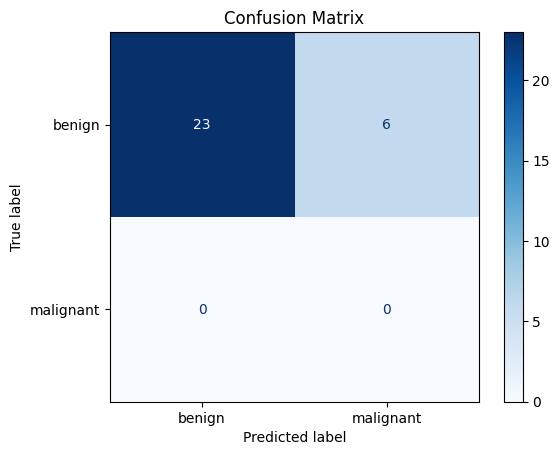

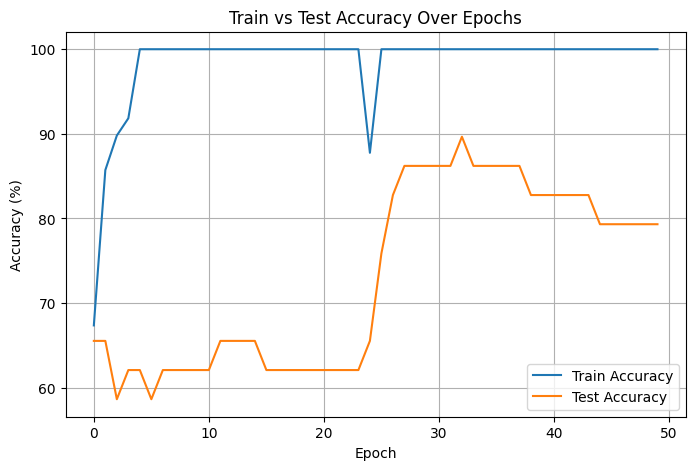

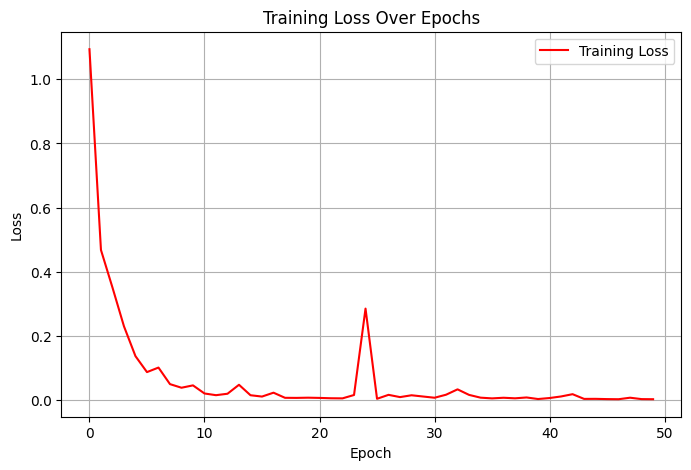


Example Predictions:


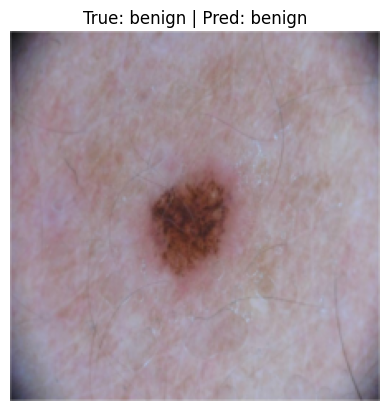

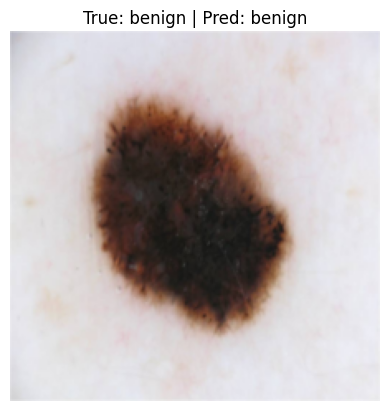

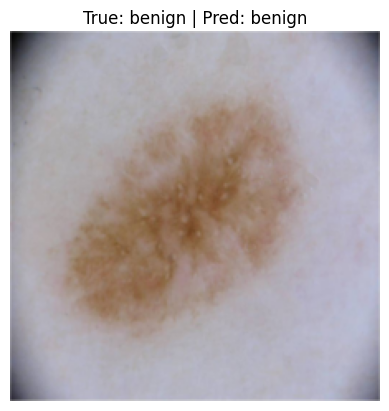

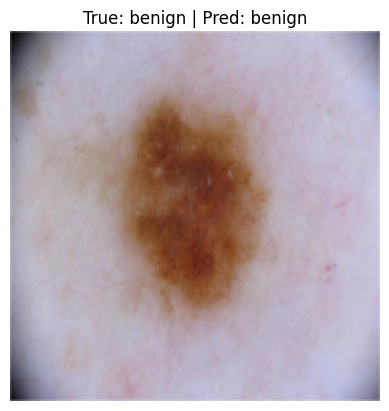

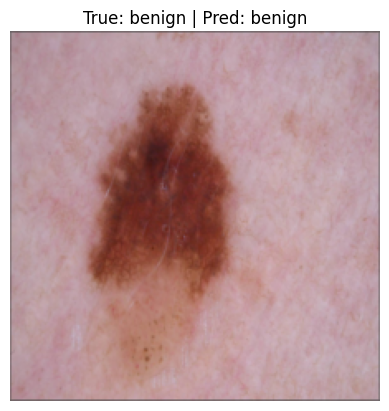

In [ ]:
# Unzip the dataset into a folder so we can access the images and labels
!unzip -o -q bme450project.zip -d bme450project

# Import all the libraries we need
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set the device to use GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define image transformations for training and testing datasets
# These help the model generalize better and keep input sizes consistent
train_image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Set paths to image folders and label CSV files
project_folder = 'bme450project/bme450project'
train_images_folder = os.path.join(project_folder, 'LesionTraining')
test_images_folder = os.path.join(project_folder, 'LesionTesting')
train_labels_file = os.path.join(project_folder, 'TrainingAnswers', 'TrainingAnswers.csv')
test_labels_file = os.path.join(project_folder, 'TestAnswers', 'TestAnswers.csv')

# Define a custom dataset class to load images and their corresponding labels
class SkinLesionDataset(Dataset):
    def __init__(self, image_folder, label_csv, transform=None):
        self.image_folder = image_folder
        self.labels = pd.read_csv(label_csv)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        filename = self.labels.iloc[index, 0] + '.jpg'
        label_text = self.labels.iloc[index, 1]
        label = 1 if str(label_text).lower() == 'malignant' else 0
        image_path = os.path.join(self.image_folder, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Load datasets and prepare them for batch processing using DataLoader
batch_size = 32
num_loader_workers = 4 if torch.cuda.is_available() else 2
training_dataset = SkinLesionDataset(train_images_folder, train_labels_file, transform=train_image_transforms)
testing_dataset = SkinLesionDataset(test_images_folder, test_labels_file, transform=test_image_transforms)
training_data_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True, num_workers=num_loader_workers, pin_memory=True)
testing_data_loader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=False, num_workers=num_loader_workers, pin_memory=True)

# Calculate a weight to balance the loss function since benign and malignant classes are imbalanced
def get_positive_class_weight(label_csv):
    label_data = pd.read_csv(label_csv)
    malignant_count = sum(label_data.iloc[:, 1].astype(str).str.lower() == 'malignant')
    benign_count = sum(label_data.iloc[:, 1].astype(str).str.lower() == 'benign')
    print(f"\nClass balance: {benign_count} benign, {malignant_count} malignant")
    return torch.tensor([benign_count / malignant_count], device=device)

positive_class_weight = get_positive_class_weight(train_labels_file)

# Load a pre-trained ResNet18 model and replace the final layer for binary classification
skin_lesion_model = models.resnet18(weights='IMAGENET1K_V1')
skin_lesion_model.fc = nn.Linear(skin_lesion_model.fc.in_features, 1)
skin_lesion_model = skin_lesion_model.to(device)

# Define the loss function and optimizer for training
loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_class_weight)
optimizer = optim.Adam(skin_lesion_model.parameters(), lr=1e-4)

# Create lists to track training progress over time
train_accuracy_history = []
test_accuracy_history = []
train_loss_history = []

# Evaluate the model's performance on the test set
def evaluate_model(model, data_loader, print_report=False):
    model.eval()
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_ground_truths = []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            predictions = (torch.sigmoid(outputs) > 0.5).squeeze().int()
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)
            all_predictions.extend(predictions.cpu().numpy())
            all_ground_truths.extend(labels.cpu().numpy())
    accuracy = 100 * total_correct / total_samples
    if print_report:
        print(f"\nFinal Test Accuracy: {accuracy:.2f}%")
        print(classification_report(all_ground_truths, all_predictions, target_names=["benign", "malignant"], zero_division=0))
        cm = confusion_matrix(all_ground_truths, all_predictions, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"]).plot(cmap='Blues')
        plt.title("Confusion Matrix")
        plt.show()
    return accuracy

# Train the model for one complete pass over the training data
def train_one_epoch(model, data_loader, optimizer, loss_function):
    model.train()
    running_loss = 0
    total_correct = 0
    total_samples = 0
    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = (torch.sigmoid(outputs) > 0.5).int()
        total_correct += (predictions.squeeze() == labels.squeeze().int()).sum().item()
        total_samples += labels.size(0)
    epoch_accuracy = 100 * total_correct / total_samples
    average_loss = running_loss / len(data_loader)
    return average_loss, epoch_accuracy

# Train the model for multiple epochs and track accuracy and loss
num_epochs = 50
for epoch in range(num_epochs):
    epoch_loss, epoch_train_accuracy = train_one_epoch(skin_lesion_model, training_data_loader, optimizer, loss_function)
    epoch_test_accuracy = evaluate_model(skin_lesion_model, testing_data_loader)
    train_loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_train_accuracy)
    test_accuracy_history.append(epoch_test_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_accuracy:.2f}% | Test Acc: {epoch_test_accuracy:.2f}%")

# Evaluate the model one final time and display full metrics and confusion matrix
evaluate_model(skin_lesion_model, testing_data_loader, print_report=True)

# Plot accuracy for both training and testing sets across all epochs
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_history, label='Train Accuracy')
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train vs Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot training loss over time to see how learning progressed
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Training Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Show a few example predictions from the test set
def show_model_predictions(model, data_loader, num_images=5):
    model.eval()
    shown = 0
    label_names = ['benign', 'malignant']
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            predictions = (torch.sigmoid(outputs) > 0.5).squeeze().int()
            for i in range(len(images)):
                if shown >= num_images:
                    return
                image_to_display = images[i].cpu().permute(1, 2, 0).numpy()
                plt.imshow(image_to_display)
                plt.title(f"True: {label_names[labels[i]]} | Pred: {label_names[predictions[i]]}")
                plt.axis('off')
                plt.show()
                shown += 1

print("\nExample Predictions:")
show_model_predictions(skin_lesion_model, testing_data_loader)
